In [11]:
from pathlib import Path
import json
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

In [12]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
FEATURE_DIR = DATA_DIR / "features"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

features_with_split_path = FEATURE_DIR / "ptb_detection_handcrafted_features_with_split.csv"
feature_columns_path = TABLE_DIR / "notebook5_model_feature_columns.json"

print("Project directory:", PROJECT_DIR)
print("Feature table exists:", features_with_split_path.exists())
print("Feature column file exists:", feature_columns_path.exists())

if not features_with_split_path.exists():
    raise FileNotFoundError("Feature table with split not found. Please run Notebook 5 first.")

if not feature_columns_path.exists():
    raise FileNotFoundError("Feature column json file not found. Please run Notebook 5 first.")

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Feature table exists: True
Feature column file exists: True


In [13]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_MID = "#B77FA0"
PURPLE_LIGHT = "#E8D3DF"
PURPLE_VERY_LIGHT = "#F5EAF1"
GRAY = "#6B6B6B"
RED_SOFT = "#C44E52"

purple_cmap = LinearSegmentedColormap.from_list(
    "custom_purple",
    ["#F8F1F5", "#E8D3DF", "#C599B6", "#8A5A78", "#4A263B"]
)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [14]:
features_df = pd.read_csv(features_with_split_path)

with open(feature_columns_path, "r", encoding="utf-8") as f:
    feature_column_info = json.load(f)

model_feature_cols = feature_column_info["model_feature_columns"]

# Rename old internal wording: qrs_anchor -> qrs_peak
rename_map = {
    col: col.replace("qrs_anchor", "qrs_peak")
    for col in features_df.columns
    if "qrs_anchor" in col
}

features_df = features_df.rename(columns=rename_map)

model_feature_cols = [
    col.replace("qrs_anchor", "qrs_peak")
    for col in model_feature_cols
]

print("Feature table shape:", features_df.shape)
print("Number of model feature columns from Notebook 5:", len(model_feature_cols))

print("\nSplit distribution:")
display(features_df["split"].value_counts())

print("\nClass distribution by split:")
display(pd.crosstab(features_df["split"], features_df["mi_detected"]))

Feature table shape: (448, 1423)
Number of model feature columns from Notebook 5: 1404

Split distribution:


split
train         308
validation     72
test           68
Name: count, dtype: int64


Class distribution by split:


mi_detected,0,1
split,,
test,12,56
train,57,251
validation,11,61


In [15]:
normalization_related_patterns = [
    "_stat_mean",
    "_stat_std",
    "_stat_var",
    "_stat_rms",
    "_stat_energy"
]

normalization_derived_cols = [
    col for col in model_feature_cols
    if any(pattern in col for pattern in normalization_related_patterns)
]

clean_feature_cols = [
    col for col in model_feature_cols
    if col not in normalization_derived_cols
]

print("Original model feature columns:", len(model_feature_cols))
print("Removed normalization-derived statistical columns:", len(normalization_derived_cols))
print("Clean feature columns:", len(clean_feature_cols))

print("\nExamples of removed columns:")
print(normalization_derived_cols[:30])

Original model feature columns: 1404
Removed normalization-derived statistical columns: 100
Clean feature columns: 1304

Examples of removed columns:
['i_stat_mean', 'i_stat_std', 'i_stat_var', 'i_stat_rms', 'i_stat_energy', 'ii_stat_mean', 'ii_stat_std', 'ii_stat_var', 'ii_stat_rms', 'ii_stat_energy', 'iii_stat_mean', 'iii_stat_std', 'iii_stat_var', 'iii_stat_rms', 'iii_stat_energy', 'avr_stat_mean', 'avr_stat_std', 'avr_stat_var', 'avr_stat_rms', 'avr_stat_energy', 'avl_stat_mean', 'avl_stat_std', 'avl_stat_var', 'avl_stat_rms', 'avl_stat_energy', 'avf_stat_mean', 'avf_stat_std', 'avf_stat_var', 'avf_stat_rms', 'avf_stat_energy']


In [16]:
train_df = features_df[features_df["split"] == "train"].copy()
val_df = features_df[features_df["split"] == "validation"].copy()
test_df = features_df[features_df["split"] == "test"].copy()

y_train = train_df["mi_detected"].astype(int)
y_val = val_df["mi_detected"].astype(int)
y_test = test_df["mi_detected"].astype(int)

print("Train records:", train_df.shape[0])
print("Validation records:", val_df.shape[0])
print("Test records:", test_df.shape[0])

print("\nTrain class distribution:")
display(y_train.value_counts())

print("\nValidation class distribution:")
display(y_val.value_counts())

print("\nTest class distribution:")
display(y_test.value_counts())

Train records: 308
Validation records: 72
Test records: 68

Train class distribution:


mi_detected
1    251
0     57
Name: count, dtype: int64


Validation class distribution:


mi_detected
1    61
0    11
Name: count, dtype: int64


Test class distribution:


mi_detected
1    56
0    12
Name: count, dtype: int64

In [17]:
LEAD_ORDER = [
    "i", "ii", "iii",
    "avr", "avl", "avf",
    "v1", "v2", "v3", "v4", "v5", "v6"
]

LEAD_DISPLAY_NAMES = {
    "i": "I",
    "ii": "II",
    "iii": "III",
    "avr": "aVR",
    "avl": "aVL",
    "avf": "aVF",
    "v1": "V1",
    "v2": "V2",
    "v3": "V3",
    "v4": "V4",
    "v5": "V5",
    "v6": "V6"
}

CLINICAL_LEAD_GROUPS = {
    "Full 12 leads": LEAD_ORDER,
    "Limb leads": ["i", "ii", "iii", "avr", "avl", "avf"],
    "Chest leads": ["v1", "v2", "v3", "v4", "v5", "v6"],
    "Inferior leads": ["ii", "iii", "avf"],
    "Anterior leads": ["v1", "v2", "v3", "v4"],
    "Lateral leads": ["i", "avl", "v5", "v6"]
}

print("Lead order:")
print(LEAD_ORDER)

print("\nClinical lead groups:")
for group_name, leads in CLINICAL_LEAD_GROUPS.items():
    print(group_name, ":", [LEAD_DISPLAY_NAMES[l] for l in leads])

Lead order:
['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']

Clinical lead groups:
Full 12 leads : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Limb leads : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF']
Chest leads : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Inferior leads : ['II', 'III', 'aVF']
Anterior leads : ['V1', 'V2', 'V3', 'V4']
Lateral leads : ['I', 'aVL', 'V5', 'V6']


In [18]:
def is_lead_specific_feature(col):
    """
    Check whether a column is a lead-specific feature.
    This excludes rhythm, group-level, and contrast-level features.
    """
    if col.startswith("rhythm_"):
        return False

    if col.startswith("contrast_"):
        return False

    if "_group_" in col:
        return False

    return any(col.startswith(f"{lead}_") for lead in LEAD_ORDER)


def get_lead_specific_features(leads, feature_cols):
    """
    Get lead-specific features for selected ECG leads.
    """
    selected_cols = []

    for col in feature_cols:
        if not is_lead_specific_feature(col):
            continue

        for lead in leads:
            if col.startswith(f"{lead}_"):
                selected_cols.append(col)
                break

    return selected_cols


def get_group_features(group_key, feature_cols):
    """
    Get group-level features for a clinical group.
    """
    group_prefix_map = {
        "Limb leads": "limb_group_",
        "Chest leads": "chest_group_",
        "Inferior leads": "inferior_group_",
        "Anterior leads": "anterior_group_",
        "Lateral leads": "lateral_group_"
    }

    if group_key not in group_prefix_map:
        return []

    prefix = group_prefix_map[group_key]

    return [
        col for col in feature_cols
        if col.startswith(prefix)
    ]


all_lead_specific_cols = [
    col for col in clean_feature_cols
    if is_lead_specific_feature(col)
]

rhythm_cols = [
    col for col in clean_feature_cols
    if col.startswith("rhythm_")
]

group_cols = [
    col for col in clean_feature_cols
    if "_group_" in col
]

contrast_cols = [
    col for col in clean_feature_cols
    if col.startswith("contrast_")
]

print("All clean features:", len(clean_feature_cols))
print("Lead-specific features:", len(all_lead_specific_cols))
print("Rhythm features:", len(rhythm_cols))
print("Group features:", len(group_cols))
print("Contrast features:", len(contrast_cols))

All clean features: 1304
Lead-specific features: 1092
Rhythm features: 12
Group features: 140
Contrast features: 60


In [19]:
def evaluate_binary_classifier(y_true, y_pred, y_score=None, model_name="model", dataset_name="dataset"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    result = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_mi": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_sensitivity_mi": sensitivity,
        "specificity_healthy": specificity,
        "f1_mi": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": (sensitivity + specificity) / 2,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

    if y_score is not None:
        try:
            result["roc_auc"] = roc_auc_score(y_true, y_score)
        except Exception:
            result["roc_auc"] = np.nan
    else:
        result["roc_auc"] = np.nan

    return result

In [20]:
def make_svm_rbf_pipeline(n_features, k_max=200, C=1.0, gamma="scale"):
    k_selected = min(k_max, n_features)

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=k_selected)),
        ("clf", SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            class_weight="balanced",
            probability=False,
            random_state=42
        ))
    ])

    return model, k_selected


def get_model_score(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    return None

In [21]:
def run_feature_set_experiment(
    feature_set_name,
    feature_cols,
    k_max=200,
    model_label="SVM RBF"
):
    """
    Train SVM RBF using a specific subset of features.
    Evaluate on validation and test sets.
    """
    feature_cols = [col for col in feature_cols if col in features_df.columns]

    if len(feature_cols) == 0:
        raise ValueError(f"No features found for feature set: {feature_set_name}")

    X_train = train_df[feature_cols].copy()
    X_val = val_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    model, k_selected = make_svm_rbf_pipeline(
        n_features=len(feature_cols),
        k_max=k_max
    )

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    y_val_score = get_model_score(model, X_val)
    y_test_score = get_model_score(model, X_test)

    val_result = evaluate_binary_classifier(
        y_val,
        y_val_pred,
        y_score=y_val_score,
        model_name=model_label,
        dataset_name="validation"
    )

    test_result = evaluate_binary_classifier(
        y_test,
        y_test_pred,
        y_score=y_test_score,
        model_name=model_label,
        dataset_name="test"
    )

    for result in [val_result, test_result]:
        result["feature_set"] = feature_set_name
        result["n_input_features"] = len(feature_cols)
        result["k_selected"] = k_selected

    return {
        "feature_set": feature_set_name,
        "feature_cols": feature_cols,
        "model": model,
        "validation_result": val_result,
        "test_result": test_result,
        "y_test_pred": y_test_pred,
        "y_test_score": y_test_score
    }

# Predefined clinical lead group analysis

In [22]:
predefined_feature_sets = {}

# Full model reference: all clean features
predefined_feature_sets["Full clean features"] = clean_feature_cols

# Strict 12-lead lead-specific only
predefined_feature_sets["Full 12 leads - lead-specific only"] = all_lead_specific_cols

# Clinical strict groups
for group_name, leads in CLINICAL_LEAD_GROUPS.items():
    predefined_feature_sets[f"{group_name} - strict"] = get_lead_specific_features(
        leads,
        clean_feature_cols
    )

# Clinical groups + corresponding group-level features
for group_name, leads in CLINICAL_LEAD_GROUPS.items():
    if group_name == "Full 12 leads":
        continue

    lead_cols = get_lead_specific_features(leads, clean_feature_cols)
    group_feature_cols = get_group_features(group_name, clean_feature_cols)

    predefined_feature_sets[f"{group_name} - strict + group features"] = (
        lead_cols + group_feature_cols
    )

print("Predefined feature sets:")
for name, cols in predefined_feature_sets.items():
    print(f"{name}: {len(cols)} features")

Predefined feature sets:
Full clean features: 1304 features
Full 12 leads - lead-specific only: 1092 features
Full 12 leads - strict: 1092 features
Limb leads - strict: 546 features
Chest leads - strict: 546 features
Inferior leads - strict: 273 features
Anterior leads - strict: 364 features
Lateral leads - strict: 364 features
Limb leads - strict + group features: 574 features
Chest leads - strict + group features: 574 features
Inferior leads - strict + group features: 301 features
Anterior leads - strict + group features: 392 features
Lateral leads - strict + group features: 392 features


In [23]:
predefined_results = []
predefined_experiment_objects = {}

for feature_set_name, cols in predefined_feature_sets.items():
    print("=" * 90)
    print("Running:", feature_set_name)
    print("Number of features:", len(cols))

    exp = run_feature_set_experiment(
        feature_set_name=feature_set_name,
        feature_cols=cols,
        k_max=200,
        model_label="SVM RBF"
    )

    predefined_experiment_objects[feature_set_name] = exp

    predefined_results.append(exp["validation_result"])
    predefined_results.append(exp["test_result"])

predefined_results_df = pd.DataFrame(predefined_results)

display(
    predefined_results_df.sort_values(
        ["dataset", "macro_f1"],
        ascending=[True, False]
    )
)

Running: Full clean features
Number of features: 1304
Running: Full 12 leads - lead-specific only
Number of features: 1092
Running: Full 12 leads - strict
Number of features: 1092
Running: Limb leads - strict
Number of features: 546
Running: Chest leads - strict
Number of features: 546
Running: Inferior leads - strict
Number of features: 273
Running: Anterior leads - strict
Number of features: 364
Running: Lateral leads - strict
Number of features: 364
Running: Limb leads - strict + group features
Number of features: 574
Running: Chest leads - strict + group features
Number of features: 574
Running: Inferior leads - strict + group features
Number of features: 301
Running: Anterior leads - strict + group features
Number of features: 392
Running: Lateral leads - strict + group features
Number of features: 392


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,feature_set,n_input_features,k_selected
11,test,SVM RBF,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,10,2,5,51,0.953869,Inferior leads - strict,273,200
21,test,SVM RBF,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,10,2,5,51,0.953869,Inferior leads - strict + group features,301,200
3,test,SVM RBF,0.882353,1.000000,0.857143,1.000000,0.923077,0.836538,0.928571,12,0,8,48,0.950893,Full 12 leads - lead-specific only,1092,200
5,test,SVM RBF,0.882353,1.000000,0.857143,1.000000,0.923077,0.836538,0.928571,12,0,8,48,0.950893,Full 12 leads - strict,1092,200
19,test,SVM RBF,0.882353,1.000000,0.857143,1.000000,0.923077,0.836538,0.928571,12,0,8,48,0.947917,Chest leads - strict + group features,574,200
7,test,SVM RBF,0.882353,0.980000,0.875000,0.916667,0.924528,0.828931,0.895833,11,1,7,49,0.959821,Limb leads - strict,546,200
17,test,SVM RBF,0.882353,0.980000,0.875000,0.916667,0.924528,0.828931,0.895833,11,1,7,49,0.955357,Limb leads - strict + group features,574,200
9,test,SVM RBF,0.867647,1.000000,0.839286,1.000000,0.912621,0.819947,0.919643,12,0,9,47,0.950893,Chest leads - strict,546,200
1,test,SVM RBF,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,11,1,9,47,0.937500,Full clean features,1304,200
15,test,SVM RBF,0.838235,0.959184,0.839286,0.833333,0.895238,0.770200,0.836310,10,2,9,47,0.955357,Lateral leads - strict,364,200


In [24]:
clinical_test_df = predefined_results_df[
    predefined_results_df["dataset"] == "test"
].copy()

clinical_test_df = clinical_test_df.sort_values("macro_f1", ascending=False)

display(clinical_test_df[
    [
        "feature_set",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp",
        "n_input_features"
    ]
])

,feature_set,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp,n_input_features
11,Inferior leads - strict,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,0.953869,10,2,5,51,273
21,Inferior leads - strict + group features,0.897059,0.962264,0.910714,0.833333,0.935780,0.838260,0.872024,0.953869,10,2,5,51,301
19,Chest leads - strict + group features,0.882353,1.000000,0.857143,1.000000,0.923077,0.836538,0.928571,0.947917,12,0,8,48,574
5,Full 12 leads - strict,0.882353,1.000000,0.857143,1.000000,0.923077,0.836538,0.928571,0.950893,12,0,8,48,1092
3,Full 12 leads - lead-specific only,0.882353,1.000000,0.857143,1.000000,0.923077,0.836538,0.928571,0.950893,12,0,8,48,1092
7,Limb leads - strict,0.882353,0.980000,0.875000,0.916667,0.924528,0.828931,0.895833,0.959821,11,1,7,49,546
17,Limb leads - strict + group features,0.882353,0.980000,0.875000,0.916667,0.924528,0.828931,0.895833,0.955357,11,1,7,49,574
9,Chest leads - strict,0.867647,1.000000,0.839286,1.000000,0.912621,0.819947,0.919643,0.950893,12,0,9,47,546
1,Full clean features,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.937500,11,1,9,47,1304
23,Anterior leads - strict + group features,0.838235,0.959184,0.839286,0.833333,0.895238,0.770200,0.836310,0.882440,10,2,9,47,392


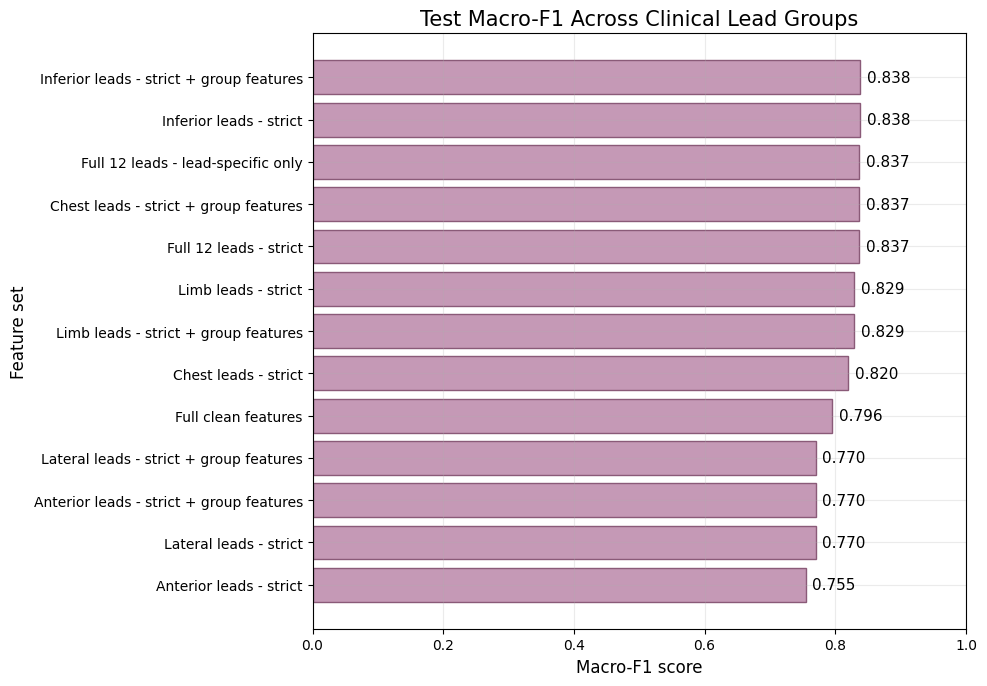

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_clinical_lead_group_macro_f1.png


In [25]:
fig_path = FIGURE_DIR / "notebook7_clinical_lead_group_macro_f1.png"

plot_df = clinical_test_df.copy()
plot_df = plot_df.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature_set"],
    plot_df["macro_f1"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Test Macro-F1 Across Clinical Lead Groups")
plt.xlabel("Macro-F1 score")
plt.ylabel("Feature set")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_df["macro_f1"]):
    plt.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# Individual lead contribution

In [26]:
single_lead_results = []
single_lead_experiment_objects = {}

for lead in LEAD_ORDER:
    lead_name = LEAD_DISPLAY_NAMES[lead]
    feature_set_name = f"Lead {lead_name}"

    cols = get_lead_specific_features([lead], clean_feature_cols)

    print("=" * 80)
    print("Running:", feature_set_name)
    print("Number of features:", len(cols))

    exp = run_feature_set_experiment(
        feature_set_name=feature_set_name,
        feature_cols=cols,
        k_max=100,
        model_label="SVM RBF"
    )

    single_lead_experiment_objects[feature_set_name] = exp

    val_result = exp["validation_result"]
    test_result = exp["test_result"]

    val_result["lead"] = lead
    val_result["lead_display"] = lead_name

    test_result["lead"] = lead
    test_result["lead_display"] = lead_name

    single_lead_results.append(val_result)
    single_lead_results.append(test_result)

single_lead_results_df = pd.DataFrame(single_lead_results)

display(
    single_lead_results_df[
        single_lead_results_df["dataset"] == "test"
    ].sort_values("macro_f1", ascending=False)
)

Running: Lead I
Number of features: 91
Running: Lead II
Number of features: 91
Running: Lead III
Number of features: 91
Running: Lead aVR
Number of features: 91
Running: Lead aVL
Number of features: 91
Running: Lead aVF
Number of features: 91
Running: Lead V1
Number of features: 91
Running: Lead V2
Number of features: 91
Running: Lead V3
Number of features: 91
Running: Lead V4
Number of features: 91
Running: Lead V5
Number of features: 91
Running: Lead V6
Number of features: 91


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,feature_set,n_input_features,k_selected,lead,lead_display
5,test,SVM RBF,0.867647,0.927273,0.910714,0.666667,0.918919,0.779459,0.788690,8,4,5,51,0.873512,Lead III,91,91,iii,III
11,test,SVM RBF,0.838235,0.959184,0.839286,0.833333,0.895238,0.770200,0.836310,10,2,9,47,0.883929,Lead aVF,91,91,avf,aVF
9,test,SVM RBF,0.852941,0.925926,0.892857,0.666667,0.909091,0.762238,0.779762,8,4,6,50,0.909226,Lead aVL,91,91,avl,aVL
23,test,SVM RBF,0.808824,0.977778,0.785714,0.916667,0.871287,0.749929,0.851190,11,1,12,44,0.925595,Lead V6,91,91,v6,V6
13,test,SVM RBF,0.823529,0.940000,0.839286,0.750000,0.886792,0.743396,0.794643,9,3,9,47,0.822917,Lead V1,91,91,v1,V1
21,test,SVM RBF,0.794118,0.977273,0.767857,0.916667,0.860000,0.735556,0.842262,11,1,13,43,0.936012,Lead V5,91,91,v5,V5
7,test,SVM RBF,0.794118,0.956522,0.785714,0.833333,0.862745,0.725490,0.809524,10,2,12,44,0.894345,Lead aVR,91,91,avr,aVR
3,test,SVM RBF,0.764706,0.934783,0.767857,0.750000,0.843137,0.686275,0.758929,9,3,13,43,0.864583,Lead II,91,91,ii,II
1,test,SVM RBF,0.735294,0.975000,0.696429,0.916667,0.812500,0.681250,0.806548,11,1,17,39,0.854167,Lead I,91,91,i,I
15,test,SVM RBF,0.735294,0.952381,0.714286,0.833333,0.816327,0.671321,0.773810,10,2,16,40,0.755952,Lead V2,91,91,v2,V2


In [27]:
single_lead_test_df = single_lead_results_df[
    single_lead_results_df["dataset"] == "test"
].copy()

single_lead_validation_df = single_lead_results_df[
    single_lead_results_df["dataset"] == "validation"
].copy()

single_lead_test_df = single_lead_test_df.sort_values("macro_f1", ascending=False)

display(single_lead_test_df[
    [
        "lead_display",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp",
        "n_input_features"
    ]
])

,lead_display,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp,n_input_features
5,III,0.867647,0.927273,0.910714,0.666667,0.918919,0.779459,0.788690,0.873512,8,4,5,51,91
11,aVF,0.838235,0.959184,0.839286,0.833333,0.895238,0.770200,0.836310,0.883929,10,2,9,47,91
9,aVL,0.852941,0.925926,0.892857,0.666667,0.909091,0.762238,0.779762,0.909226,8,4,6,50,91
23,V6,0.808824,0.977778,0.785714,0.916667,0.871287,0.749929,0.851190,0.925595,11,1,12,44,91
13,V1,0.823529,0.940000,0.839286,0.750000,0.886792,0.743396,0.794643,0.822917,9,3,9,47,91
21,V5,0.794118,0.977273,0.767857,0.916667,0.860000,0.735556,0.842262,0.936012,11,1,13,43,91
7,aVR,0.794118,0.956522,0.785714,0.833333,0.862745,0.725490,0.809524,0.894345,10,2,12,44,91
3,II,0.764706,0.934783,0.767857,0.750000,0.843137,0.686275,0.758929,0.864583,9,3,13,43,91
1,I,0.735294,0.975000,0.696429,0.916667,0.812500,0.681250,0.806548,0.854167,11,1,17,39,91
15,V2,0.735294,0.952381,0.714286,0.833333,0.816327,0.671321,0.773810,0.755952,10,2,16,40,91


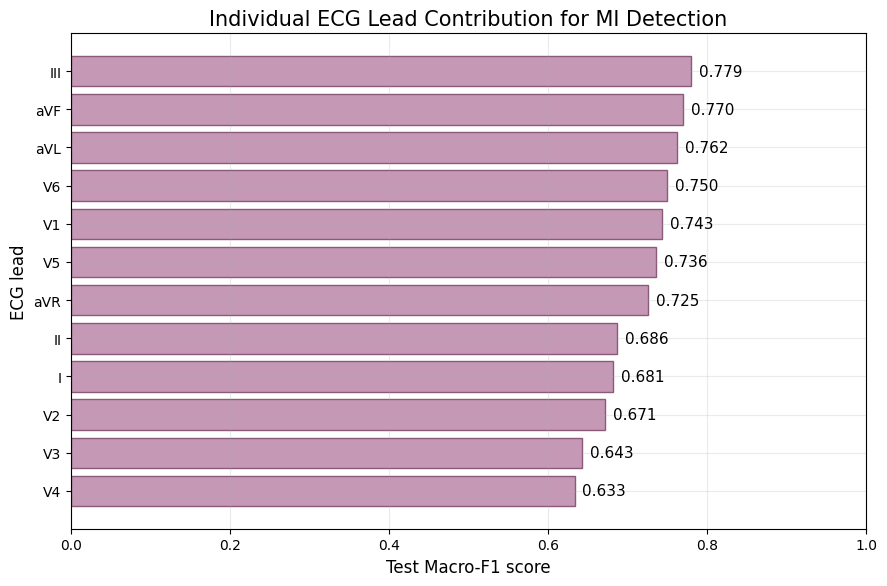

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_single_lead_macro_f1_ranking.png


In [28]:
fig_path = FIGURE_DIR / "notebook7_single_lead_macro_f1_ranking.png"

plot_df = single_lead_test_df.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["lead_display"],
    plot_df["macro_f1"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Individual ECG Lead Contribution for MI Detection")
plt.xlabel("Test Macro-F1 score")
plt.ylabel("ECG lead")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_df["macro_f1"]):
    plt.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

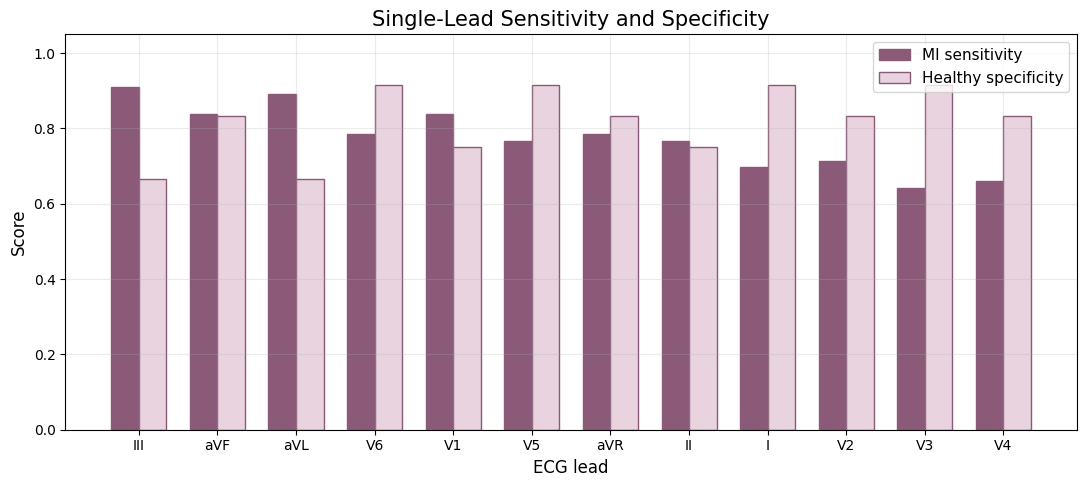

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_single_lead_sensitivity_specificity.png


In [29]:
fig_path = FIGURE_DIR / "notebook7_single_lead_sensitivity_specificity.png"

plot_df = single_lead_test_df.copy()
plot_df = plot_df.sort_values("macro_f1", ascending=False)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 5))

plt.bar(
    x - width / 2,
    plot_df["recall_sensitivity_mi"],
    width,
    label="MI sensitivity",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + width / 2,
    plot_df["specificity_healthy"],
    width,
    label="Healthy specificity",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.title("Single-Lead Sensitivity and Specificity")
plt.xlabel("ECG lead")
plt.ylabel("Score")
plt.xticks(x, plot_df["lead_display"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# Progressive top-k lead combinations

In [30]:
lead_validation_ranking_df = single_lead_validation_df.sort_values(
    ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
    ascending=False
).copy()

lead_ranking = lead_validation_ranking_df["lead"].tolist()

print("Lead ranking based on validation macro-F1:")
print([LEAD_DISPLAY_NAMES[lead] for lead in lead_ranking])

display(lead_validation_ranking_df[
    [
        "lead_display",
        "accuracy",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc"
    ]
])

Lead ranking based on validation macro-F1:
['V5', 'V6', 'V4', 'II', 'aVR', 'I', 'aVF', 'III', 'V3', 'aVL', 'V2', 'V1']


,lead_display,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,balanced_accuracy,roc_auc
20,V5,0.902778,0.901639,0.909091,0.840456,0.905365,0.983607
22,V6,0.847222,0.836066,0.909091,0.773908,0.872578,0.955291
18,V4,0.805556,0.786885,0.909091,0.730481,0.847988,0.889717
2,II,0.791667,0.786885,0.818182,0.705160,0.802534,0.889717
6,aVR,0.791667,0.786885,0.818182,0.705160,0.802534,0.871833
0,I,0.750000,0.721311,0.909091,0.678252,0.815201,0.865872
10,aVF,0.777778,0.819672,0.545455,0.645320,0.682563,0.803279
4,III,0.750000,0.770492,0.636364,0.638393,0.703428,0.785395
16,V3,0.694444,0.655738,0.909091,0.630252,0.782414,0.877794
8,aVL,0.750000,0.786885,0.545455,0.621053,0.666170,0.757079


In [31]:
topk_results = []
topk_experiment_objects = {}

for k in range(1, len(LEAD_ORDER) + 1):
    selected_leads = lead_ranking[:k]
    selected_lead_names = [LEAD_DISPLAY_NAMES[lead] for lead in selected_leads]

    feature_set_name = "Top " + str(k) + " leads: " + " + ".join(selected_lead_names)

    cols = get_lead_specific_features(selected_leads, clean_feature_cols)

    print("=" * 90)
    print("Running:", feature_set_name)
    print("Number of features:", len(cols))

    exp = run_feature_set_experiment(
        feature_set_name=feature_set_name,
        feature_cols=cols,
        k_max=200,
        model_label="SVM RBF"
    )

    topk_experiment_objects[feature_set_name] = exp

    for result in [exp["validation_result"], exp["test_result"]]:
        result["n_leads"] = k
        result["lead_combination"] = " + ".join(selected_lead_names)
        topk_results.append(result)

topk_results_df = pd.DataFrame(topk_results)

display(
    topk_results_df[topk_results_df["dataset"] == "test"][
        [
            "n_leads",
            "lead_combination",
            "accuracy",
            "recall_sensitivity_mi",
            "specificity_healthy",
            "macro_f1",
            "balanced_accuracy",
            "roc_auc",
            "tn", "fp", "fn", "tp"
        ]
    ]
)

Running: Top 1 leads: V5
Number of features: 91
Running: Top 2 leads: V5 + V6
Number of features: 182
Running: Top 3 leads: V5 + V6 + V4
Number of features: 273
Running: Top 4 leads: V5 + V6 + V4 + II
Number of features: 364
Running: Top 5 leads: V5 + V6 + V4 + II + aVR
Number of features: 455
Running: Top 6 leads: V5 + V6 + V4 + II + aVR + I
Number of features: 546
Running: Top 7 leads: V5 + V6 + V4 + II + aVR + I + aVF
Number of features: 637
Running: Top 8 leads: V5 + V6 + V4 + II + aVR + I + aVF + III
Number of features: 728
Running: Top 9 leads: V5 + V6 + V4 + II + aVR + I + aVF + III + V3
Number of features: 819
Running: Top 10 leads: V5 + V6 + V4 + II + aVR + I + aVF + III + V3 + aVL
Number of features: 910
Running: Top 11 leads: V5 + V6 + V4 + II + aVR + I + aVF + III + V3 + aVL + V2
Number of features: 1001
Running: Top 12 leads: V5 + V6 + V4 + II + aVR + I + aVF + III + V3 + aVL + V2 + V1
Number of features: 1092


,n_leads,lead_combination,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
1,1,V5,0.794118,0.767857,0.916667,0.735556,0.842262,0.936012,11,1,13,43
3,2,V5 + V6,0.808824,0.767857,1.000000,0.758668,0.883929,0.924107,12,0,13,43
5,3,V5 + V6 + V4,0.779412,0.750000,0.916667,0.721540,0.833333,0.888393,11,1,14,42
7,4,V5 + V6 + V4 + II,0.794118,0.767857,0.916667,0.735556,0.842262,0.886905,11,1,13,43
9,5,V5 + V6 + V4 + II + aVR,0.808824,0.767857,1.000000,0.758668,0.883929,0.898810,12,0,13,43
11,6,V5 + V6 + V4 + II + aVR + I,0.779412,0.732143,1.000000,0.730373,0.866071,0.909226,12,0,15,41
13,7,V5 + V6 + V4 + II + aVR + I + aVF,0.852941,0.821429,1.000000,0.803922,0.910714,0.927083,12,0,10,46
15,8,V5 + V6 + V4 + II + aVR + I + aVF + III,0.838235,0.821429,0.916667,0.779935,0.869048,0.927083,11,1,10,46
17,9,V5 + V6 + V4 + II + aVR + I + aVF + III + V3,0.852941,0.821429,1.000000,0.803922,0.910714,0.934524,12,0,10,46
19,10,V5 + V6 + V4 + II + aVR + I + aVF + III + V3 +...,0.867647,0.839286,1.000000,0.819947,0.919643,0.941964,12,0,9,47


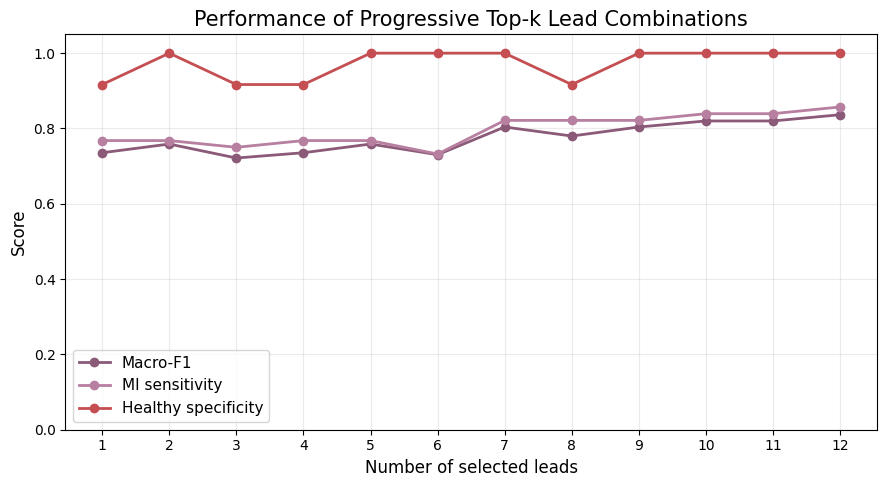

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_topk_lead_combination_performance.png


In [32]:
fig_path = FIGURE_DIR / "notebook7_topk_lead_combination_performance.png"

topk_test_df = topk_results_df[topk_results_df["dataset"] == "test"].copy()

plt.figure(figsize=(9, 5))

plt.plot(
    topk_test_df["n_leads"],
    topk_test_df["macro_f1"],
    marker="o",
    linewidth=2,
    color=PURPLE_DARK,
    label="Macro-F1"
)

plt.plot(
    topk_test_df["n_leads"],
    topk_test_df["recall_sensitivity_mi"],
    marker="o",
    linewidth=2,
    color=PURPLE_MID,
    label="MI sensitivity"
)

plt.plot(
    topk_test_df["n_leads"],
    topk_test_df["specificity_healthy"],
    marker="o",
    linewidth=2,
    color=RED_SOFT,
    label="Healthy specificity"
)

plt.title("Performance of Progressive Top-k Lead Combinations")
plt.xlabel("Number of selected leads")
plt.ylabel("Score")
plt.xticks(range(1, len(LEAD_ORDER) + 1))
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# Exhaustive 2-lead and 3-lead combination search

In [33]:
# Cell 23
def run_exhaustive_lead_combinations(combo_size, k_max=150):
    combo_results = []

    lead_combos = list(combinations(LEAD_ORDER, combo_size))

    print(f"Running exhaustive {combo_size}-lead combinations")
    print("Number of combinations:", len(lead_combos))

    for idx, combo in enumerate(lead_combos, start=1):
        combo = list(combo)
        combo_display = " + ".join([LEAD_DISPLAY_NAMES[lead] for lead in combo])
        feature_set_name = f"{combo_size}-lead combo: {combo_display}"

        cols = get_lead_specific_features(combo, clean_feature_cols)

        print(f"[{idx}/{len(lead_combos)}] {combo_display} — {len(cols)} features")

        exp = run_feature_set_experiment(
            feature_set_name=feature_set_name,
            feature_cols=cols,
            k_max=k_max,
            model_label="SVM RBF"
        )

        for result in [exp["validation_result"], exp["test_result"]]:
            result["combo_size"] = combo_size
            result["lead_combination"] = combo_display
            result["leads"] = "+".join(combo)
            combo_results.append(result)

    return pd.DataFrame(combo_results)

In [34]:
combo2_results_df = run_exhaustive_lead_combinations(
    combo_size=2,
    k_max=150
)

combo2_test_df = combo2_results_df[
    combo2_results_df["dataset"] == "test"
].sort_values("macro_f1", ascending=False)

display(combo2_test_df.head(15)[
    [
        "lead_combination",
        "accuracy",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp",
        "n_input_features"
    ]
])

Running exhaustive 2-lead combinations
Number of combinations: 66
[1/66] I + II — 182 features
[2/66] I + III — 182 features
[3/66] I + aVR — 182 features
[4/66] I + aVL — 182 features
[5/66] I + aVF — 182 features
[6/66] I + V1 — 182 features
[7/66] I + V2 — 182 features
[8/66] I + V3 — 182 features
[9/66] I + V4 — 182 features
[10/66] I + V5 — 182 features
[11/66] I + V6 — 182 features
[12/66] II + III — 182 features
[13/66] II + aVR — 182 features
[14/66] II + aVL — 182 features
[15/66] II + aVF — 182 features
[16/66] II + V1 — 182 features
[17/66] II + V2 — 182 features
[18/66] II + V3 — 182 features
[19/66] II + V4 — 182 features
[20/66] II + V5 — 182 features
[21/66] II + V6 — 182 features
[22/66] III + aVR — 182 features
[23/66] III + aVL — 182 features
[24/66] III + aVF — 182 features
[25/66] III + V1 — 182 features
[26/66] III + V2 — 182 features
[27/66] III + V3 — 182 features
[28/66] III + V4 — 182 features
[29/66] III + V5 — 182 features
[30/66] III + V6 — 182 features
[31/

,lead_combination,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp,n_input_features
59,III + V6,0.926471,0.928571,0.916667,0.884472,0.922619,0.946429,11,1,4,52,182
27,II + aVL,0.911765,0.892857,1.000000,0.871698,0.946429,0.959821,12,0,6,50,182
89,aVL + V6,0.897059,0.892857,0.916667,0.846600,0.904762,0.943452,11,1,6,50,182
23,II + III,0.897059,0.910714,0.833333,0.838260,0.872024,0.965774,10,2,5,51,182
79,aVL + V1,0.897059,0.910714,0.833333,0.838260,0.872024,0.919643,10,2,5,51,182
109,V1 + V5,0.882353,0.857143,1.000000,0.836538,0.928571,0.962798,12,0,8,48,182
101,aVF + V6,0.882353,0.875000,0.916667,0.828931,0.895833,0.928571,11,1,7,49,182
111,V1 + V6,0.882353,0.875000,0.916667,0.828931,0.895833,0.961310,11,1,7,49,182
47,III + aVF,0.897059,0.928571,0.750000,0.828468,0.839286,0.937500,9,3,4,52,182
49,III + V1,0.882353,0.892857,0.833333,0.820106,0.863095,0.892857,10,2,6,50,182


In [35]:
combo3_results_df = run_exhaustive_lead_combinations(
    combo_size=3,
    k_max=150
)

combo3_test_df = combo3_results_df[
    combo3_results_df["dataset"] == "test"
].sort_values("macro_f1", ascending=False)

display(combo3_test_df.head(15)[
    [
        "lead_combination",
        "accuracy",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp",
        "n_input_features"
    ]
])

Running exhaustive 3-lead combinations
Number of combinations: 220
[1/220] I + II + III — 273 features
[2/220] I + II + aVR — 273 features
[3/220] I + II + aVL — 273 features
[4/220] I + II + aVF — 273 features
[5/220] I + II + V1 — 273 features
[6/220] I + II + V2 — 273 features
[7/220] I + II + V3 — 273 features
[8/220] I + II + V4 — 273 features
[9/220] I + II + V5 — 273 features
[10/220] I + II + V6 — 273 features
[11/220] I + III + aVR — 273 features
[12/220] I + III + aVL — 273 features
[13/220] I + III + aVF — 273 features
[14/220] I + III + V1 — 273 features
[15/220] I + III + V2 — 273 features
[16/220] I + III + V3 — 273 features
[17/220] I + III + V4 — 273 features
[18/220] I + III + V5 — 273 features
[19/220] I + III + V6 — 273 features
[20/220] I + aVR + aVL — 273 features
[21/220] I + aVR + aVF — 273 features
[22/220] I + aVR + V1 — 273 features
[23/220] I + aVR + V2 — 273 features
[24/220] I + aVR + V3 — 273 features
[25/220] I + aVR + V4 — 273 features
[26/220] I + aVR +

,lead_combination,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp,n_input_features
229,III + aVL + V6,0.926471,0.928571,0.916667,0.884472,0.922619,0.959821,11,1,4,52,273
347,aVL + V1 + V5,0.926471,0.928571,0.916667,0.884472,0.922619,0.959821,11,1,4,52,273
241,III + aVF + V6,0.926471,0.928571,0.916667,0.884472,0.922619,0.955357,11,1,4,52,273
151,II + aVL + V3,0.911765,0.892857,1.000000,0.871698,0.946429,0.958333,12,0,6,50,273
363,aVL + V3 + V6,0.911765,0.892857,1.000000,0.871698,0.946429,0.934524,12,0,6,50,273
377,aVF + V1 + V5,0.911765,0.892857,1.000000,0.871698,0.946429,0.952381,12,0,6,50,273
419,V1 + V5 + V6,0.911765,0.892857,1.000000,0.871698,0.946429,0.962798,12,0,6,50,273
251,III + V1 + V6,0.911765,0.910714,0.916667,0.865079,0.913690,0.965774,11,1,5,51,273
349,aVL + V1 + V6,0.911765,0.910714,0.916667,0.865079,0.913690,0.958333,11,1,5,51,273
115,II + III + aVF,0.911765,0.928571,0.833333,0.857343,0.880952,0.964286,10,2,4,52,273


In [36]:
all_combo_results_df = pd.concat(
    [
        combo2_results_df,
        combo3_results_df
    ],
    ignore_index=True
)

all_combo_test_df = all_combo_results_df[
    all_combo_results_df["dataset"] == "test"
].copy()

all_combo_validation_df = all_combo_results_df[
    all_combo_results_df["dataset"] == "validation"
].copy()

print("All combination results shape:", all_combo_results_df.shape)

print("\nTop 20 test combinations:")
display(all_combo_test_df.sort_values("macro_f1", ascending=False).head(20)[
    [
        "combo_size",
        "lead_combination",
        "accuracy",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp"
    ]
])

All combination results shape: (572, 20)

Top 20 test combinations:


,combo_size,lead_combination,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
59,2,III + V6,0.926471,0.928571,0.916667,0.884472,0.922619,0.946429,11,1,4,52
479,3,aVL + V1 + V5,0.926471,0.928571,0.916667,0.884472,0.922619,0.959821,11,1,4,52
373,3,III + aVF + V6,0.926471,0.928571,0.916667,0.884472,0.922619,0.955357,11,1,4,52
361,3,III + aVL + V6,0.926471,0.928571,0.916667,0.884472,0.922619,0.959821,11,1,4,52
495,3,aVL + V3 + V6,0.911765,0.892857,1.000000,0.871698,0.946429,0.934524,12,0,6,50
509,3,aVF + V1 + V5,0.911765,0.892857,1.000000,0.871698,0.946429,0.952381,12,0,6,50
551,3,V1 + V5 + V6,0.911765,0.892857,1.000000,0.871698,0.946429,0.962798,12,0,6,50
283,3,II + aVL + V3,0.911765,0.892857,1.000000,0.871698,0.946429,0.958333,12,0,6,50
27,2,II + aVL,0.911765,0.892857,1.000000,0.871698,0.946429,0.959821,12,0,6,50
481,3,aVL + V1 + V6,0.911765,0.910714,0.916667,0.865079,0.913690,0.958333,11,1,5,51


In [37]:
best_combo_val_row = all_combo_validation_df.sort_values(
    ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
    ascending=False
).iloc[0]

best_combo_name = best_combo_val_row["lead_combination"]
best_combo_leads_internal = best_combo_val_row["leads"].split("+")

print("Best reduced lead combination selected on validation set:")
print(best_combo_name)

display(best_combo_val_row)

best_combo_test_row = all_combo_test_df[
    all_combo_test_df["leads"] == best_combo_val_row["leads"]
].iloc[0]

print("\nCorresponding test performance:")
display(best_combo_test_row)

Best reduced lead combination selected on validation set:
V2 + V3 + V5


dataset                                  validation
model                                       SVM RBF
accuracy                                   0.944444
precision_mi                                    1.0
recall_sensitivity_mi                      0.934426
specificity_healthy                             1.0
f1_mi                                      0.966102
macro_f1                                   0.906128
balanced_accuracy                          0.967213
tn                                               11
fp                                                0
fn                                                4
tp                                               57
roc_auc                                    0.997019
feature_set              3-lead combo: V2 + V3 + V5
n_input_features                                273
k_selected                                      150
combo_size                                        3
lead_combination                       V2 + V3 + V5
leads       


Corresponding test performance:


dataset                                        test
model                                       SVM RBF
accuracy                                   0.764706
precision_mi                                    1.0
recall_sensitivity_mi                      0.714286
specificity_healthy                             1.0
f1_mi                                      0.833333
macro_f1                                   0.716667
balanced_accuracy                          0.857143
tn                                               12
fp                                                0
fn                                               16
tp                                               40
roc_auc                                    0.922619
feature_set              3-lead combo: V2 + V3 + V5
n_input_features                                273
k_selected                                      150
combo_size                                        3
lead_combination                       V2 + V3 + V5
leads       

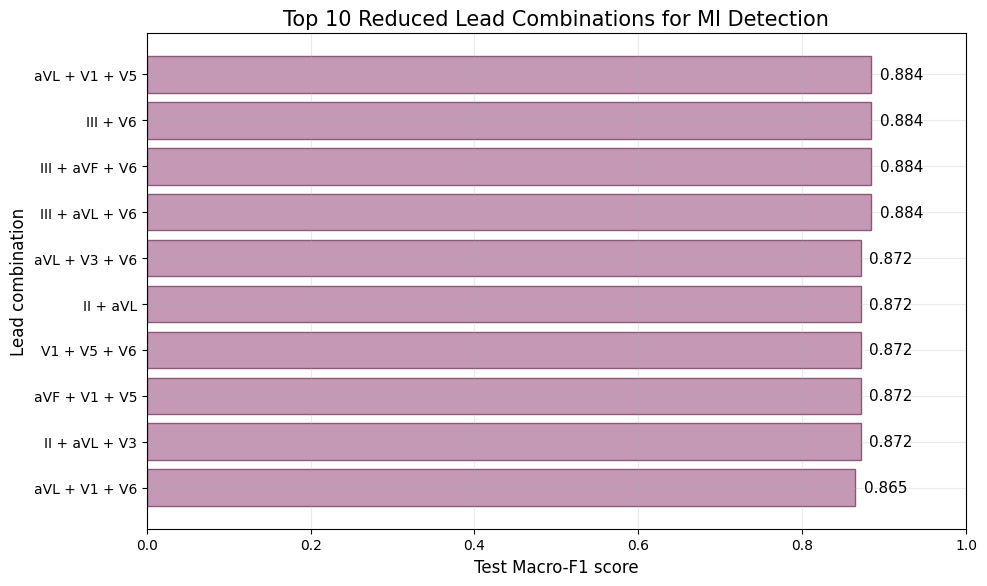

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_top10_reduced_lead_combinations.png


In [38]:
fig_path = FIGURE_DIR / "notebook7_top10_reduced_lead_combinations.png"

plot_df = all_combo_test_df.sort_values("macro_f1", ascending=False).head(10).copy()
plot_df = plot_df.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["lead_combination"],
    plot_df["macro_f1"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Top 10 Reduced Lead Combinations for MI Detection")
plt.xlabel("Test Macro-F1 score")
plt.ylabel("Lead combination")
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_df["macro_f1"]):
    plt.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# 2-lead heatmap

In [39]:
combo2_test_for_heatmap = combo2_results_df[
    combo2_results_df["dataset"] == "test"
].copy()

heatmap_matrix = pd.DataFrame(
    np.nan,
    index=LEAD_ORDER,
    columns=LEAD_ORDER
)

for _, row in combo2_test_for_heatmap.iterrows():
    leads = row["leads"].split("+")
    lead_a, lead_b = leads[0], leads[1]
    value = row["macro_f1"]

    heatmap_matrix.loc[lead_a, lead_b] = value
    heatmap_matrix.loc[lead_b, lead_a] = value

display(heatmap_matrix)

,i,ii,iii,avr,avl,avf,v1,v2,v3,v4,v5,v6
i,NaN,0.779935,0.811982,0.735556,0.802772,0.811982,0.749929,0.660000,0.655522,0.608902,0.725490,0.735556
ii,0.779935,NaN,0.838260,0.739924,0.871698,0.745838,0.743396,0.764706,0.735556,0.686275,0.773333,0.786164
iii,0.811982,0.838260,NaN,0.770200,0.809790,0.828468,0.820106,0.730159,0.802772,0.786164,0.779935,0.884472
avr,0.735556,0.739924,0.770200,NaN,0.802772,0.779935,0.770200,0.764706,0.749929,0.697778,0.744361,0.725490
avl,0.802772,0.871698,0.809790,0.802772,NaN,0.820106,0.838260,0.743396,0.743396,0.728418,0.786164,0.846600
avf,0.811982,0.745838,0.828468,0.779935,0.820106,NaN,0.820106,0.700629,0.811982,0.770200,0.811982,0.828931
v1,0.749929,0.743396,0.820106,0.770200,0.838260,0.820106,NaN,0.713942,0.739924,0.764706,0.836538,0.828931
v2,0.660000,0.764706,0.730159,0.764706,0.743396,0.700629,0.713942,NaN,0.633376,0.684412,0.758668,0.764706
v3,0.655522,0.735556,0.802772,0.749929,0.743396,0.811982,0.739924,0.633376,NaN,0.645833,0.758668,0.735556
v4,0.608902,0.686275,0.786164,0.697778,0.728418,0.770200,0.764706,0.684412,0.645833,NaN,0.735556,0.711457


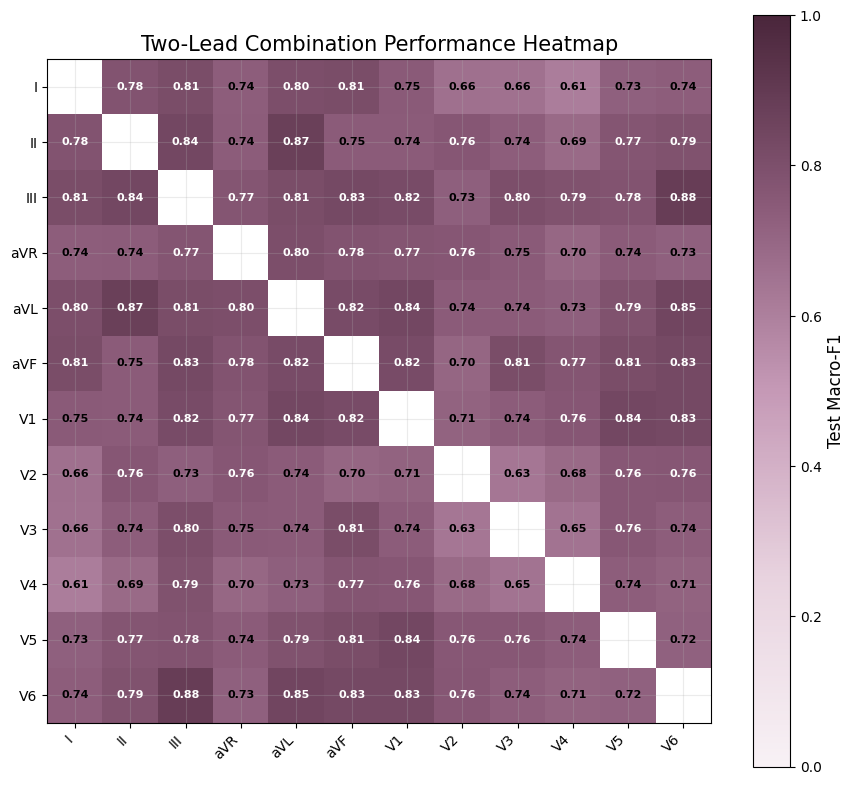

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_2lead_combination_heatmap.png


In [40]:
fig_path = FIGURE_DIR / "notebook7_2lead_combination_heatmap.png"

plt.figure(figsize=(9, 8))

im = plt.imshow(
    heatmap_matrix,
    cmap=purple_cmap,
    vmin=0,
    vmax=1
)

plt.colorbar(im, label="Test Macro-F1")

plt.xticks(
    ticks=np.arange(len(LEAD_ORDER)),
    labels=[LEAD_DISPLAY_NAMES[lead] for lead in LEAD_ORDER],
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(LEAD_ORDER)),
    labels=[LEAD_DISPLAY_NAMES[lead] for lead in LEAD_ORDER]
)

plt.title("Two-Lead Combination Performance Heatmap")

for i in range(len(LEAD_ORDER)):
    for j in range(len(LEAD_ORDER)):
        value = heatmap_matrix.iloc[i, j]

        if np.isfinite(value):
            text_color = "white" if value >= 0.75 else "black"

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=8,
                fontweight="bold"
            )

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# Compare full model vs best reduced combination

In [47]:
# Cell 31
best_reduced_cols = get_lead_specific_features(
    best_combo_leads_internal,
    clean_feature_cols
)

best_reduced_exp = run_feature_set_experiment(
    feature_set_name=f"Best reduced combo: {best_combo_name}",
    feature_cols=best_reduced_cols,
    k_max=int(best_combo_val_row["k_selected"]),
    model_label="SVM RBF"
)

best_reduced_test_result = best_reduced_exp["test_result"]

print("Best reduced combination test result:")
display(pd.DataFrame([best_reduced_test_result]))

Best reduced combination test result:


,dataset,model,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,tn,fp,fn,tp,roc_auc,feature_set,n_input_features,k_selected
0,test,SVM RBF,0.764706,1.0,0.714286,1.0,0.833333,0.716667,0.857143,12,0,16,40,0.922619,Best reduced combo: V2 + V3 + V5,273,150


In [42]:
# Full model vs best reduced combination comparison
full_clean_test_row = clinical_test_df[
    clinical_test_df["feature_set"] == "Full clean features"
].iloc[0]

full_12_strict_test_row = clinical_test_df[
    clinical_test_df["feature_set"] == "Full 12 leads - lead-specific only"
].iloc[0]

comparison_rows = [
    {
        "setting": "Full clean features",
        **full_clean_test_row.to_dict()
    },
    {
        "setting": "Full 12 leads - lead-specific only",
        **full_12_strict_test_row.to_dict()
    },
    {
        "setting": f"Best reduced combo: {best_combo_name}",
        **best_reduced_test_result
    }
]

full_vs_reduced_df = pd.DataFrame(comparison_rows)

display(full_vs_reduced_df[
    [
        "setting",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp",
        "n_input_features"
    ]
])

,setting,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp,n_input_features
0,Full clean features,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.937500,11,1,9,47,1304
1,Full 12 leads - lead-specific only,0.882353,1.000000,0.857143,1.000000,0.923077,0.836538,0.928571,0.950893,12,0,8,48,1092
2,Best reduced combo: V2 + V3 + V5,0.808824,1.000000,0.767857,1.000000,0.868687,0.758668,0.883929,0.918155,12,0,13,43,273


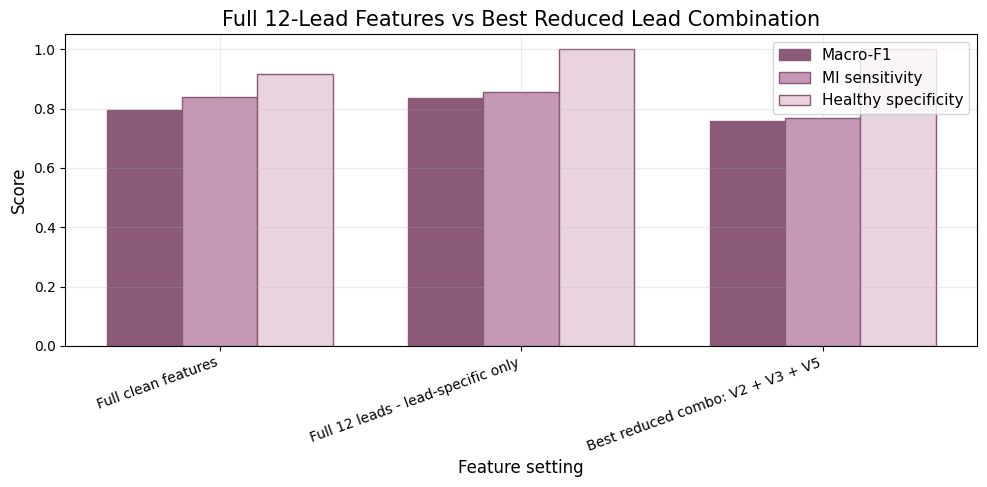

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_full_vs_reduced_comparison.png


In [43]:
fig_path = FIGURE_DIR / "notebook7_full_vs_reduced_comparison.png"

plot_df = full_vs_reduced_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    plot_df["macro_f1"],
    width,
    label="Macro-F1",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x,
    plot_df["recall_sensitivity_mi"],
    width,
    label="MI sensitivity",
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + width,
    plot_df["specificity_healthy"],
    width,
    label="Healthy specificity",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.title("Full 12-Lead Features vs Best Reduced Lead Combination")
plt.xlabel("Feature setting")
plt.ylabel("Score")
plt.xticks(x, plot_df["setting"], rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# Near-12 lead combinations

In [48]:
# =========================
# Near-12 lead combination analysis
# =========================

near12_results = []

for combo_size in [10, 11]:
    print("=" * 90)
    print(f"Running exhaustive {combo_size}-lead combinations")

    combo_df = run_exhaustive_lead_combinations(
        combo_size=combo_size,
        k_max=200
    )

    near12_results.append(combo_df)

near12_results_df = pd.concat(near12_results, ignore_index=True)

near12_test_df = near12_results_df[
    near12_results_df["dataset"] == "test"
].copy()

near12_validation_df = near12_results_df[
    near12_results_df["dataset"] == "validation"
].copy()

print("Near-12 results shape:", near12_results_df.shape)

print("\nTop 15 near-12 combinations by test macro-F1:")
display(
    near12_test_df
    .sort_values("macro_f1", ascending=False)
    .head(15)[
        [
            "combo_size",
            "lead_combination",
            "accuracy",
            "recall_sensitivity_mi",
            "specificity_healthy",
            "macro_f1",
            "balanced_accuracy",
            "roc_auc",
            "tn", "fp", "fn", "tp",
            "n_input_features"
        ]
    ]
)

Running exhaustive 10-lead combinations
Running exhaustive 10-lead combinations
Number of combinations: 66
[1/66] I + II + III + aVR + aVL + aVF + V1 + V2 + V3 + V4 — 910 features
[2/66] I + II + III + aVR + aVL + aVF + V1 + V2 + V3 + V5 — 910 features
[3/66] I + II + III + aVR + aVL + aVF + V1 + V2 + V3 + V6 — 910 features
[4/66] I + II + III + aVR + aVL + aVF + V1 + V2 + V4 + V5 — 910 features
[5/66] I + II + III + aVR + aVL + aVF + V1 + V2 + V4 + V6 — 910 features
[6/66] I + II + III + aVR + aVL + aVF + V1 + V2 + V5 + V6 — 910 features
[7/66] I + II + III + aVR + aVL + aVF + V1 + V3 + V4 + V5 — 910 features
[8/66] I + II + III + aVR + aVL + aVF + V1 + V3 + V4 + V6 — 910 features
[9/66] I + II + III + aVR + aVL + aVF + V1 + V3 + V5 + V6 — 910 features
[10/66] I + II + III + aVR + aVL + aVF + V1 + V4 + V5 + V6 — 910 features
[11/66] I + II + III + aVR + aVL + aVF + V2 + V3 + V4 + V5 — 910 features
[12/66] I + II + III + aVR + aVL + aVF + V2 + V3 + V4 + V6 — 910 features
[13/66] I + II

,combo_size,lead_combination,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp,n_input_features
127,10,II + III + aVL + aVF + V1 + V2 + V3 + V4 + V5 ...,0.926471,0.910714,1.0,0.890429,0.955357,0.952381,12,0,5,51,910
131,10,III + aVR + aVL + aVF + V1 + V2 + V3 + V4 + V5...,0.911765,0.892857,1.0,0.871698,0.946429,0.955357,12,0,6,50,910
115,10,II + III + aVR + aVL + aVF + V1 + V2 + V3 + V5...,0.911765,0.892857,1.0,0.871698,0.946429,0.955357,12,0,6,50,910
107,10,I + III + aVL + aVF + V1 + V2 + V3 + V4 + V5 + V6,0.911765,0.892857,1.0,0.871698,0.946429,0.947917,12,0,6,50,910
61,10,I + II + III + aVL + aVF + V1 + V2 + V3 + V5 + V6,0.911765,0.892857,1.0,0.871698,0.946429,0.958333,12,0,6,50,910
103,10,I + III + aVR + aVL + V1 + V2 + V3 + V4 + V5 + V6,0.911765,0.892857,1.0,0.871698,0.946429,0.950893,12,0,6,50,910
35,10,I + II + III + aVR + aVL + V1 + V2 + V3 + V5 + V6,0.897059,0.875000,1.0,0.853763,0.937500,0.956845,12,0,7,49,910
37,10,I + II + III + aVR + aVL + V1 + V2 + V4 + V5 + V6,0.897059,0.875000,1.0,0.853763,0.937500,0.946429,12,0,7,49,910
3,10,I + II + III + aVR + aVL + aVF + V1 + V2 + V3 ...,0.897059,0.875000,1.0,0.853763,0.937500,0.956845,12,0,7,49,910
7,10,I + II + III + aVR + aVL + aVF + V1 + V2 + V4 ...,0.897059,0.875000,1.0,0.853763,0.937500,0.946429,12,0,7,49,910


In [49]:
# Cell 38
# =========================
# Select best near-12 lead combination using validation set
# =========================

best_near12_val_row = near12_validation_df.sort_values(
    ["macro_f1", "roc_auc", "recall_sensitivity_mi"],
    ascending=False
).iloc[0]

best_near12_leads = best_near12_val_row["leads"]
best_near12_name = best_near12_val_row["lead_combination"]

print("Best near-12 combination selected on validation set:")
print(best_near12_name)

display(best_near12_val_row)

best_near12_test_row = near12_test_df[
    near12_test_df["leads"] == best_near12_leads
].iloc[0]

print("\nCorresponding test performance:")
display(best_near12_test_row)

Best near-12 combination selected on validation set:
I + II + aVR + aVL + aVF + V1 + V2 + V3 + V4 + V5 + V6


dataset                                                         validation
model                                                              SVM RBF
accuracy                                                          0.916667
precision_mi                                                      0.982456
recall_sensitivity_mi                                             0.918033
specificity_healthy                                               0.909091
f1_mi                                                             0.949153
macro_f1                                                          0.859192
balanced_accuracy                                                 0.913562
tn                                                                      10
fp                                                                       1
fn                                                                       5
tp                                                                      56
roc_auc                  


Corresponding test performance:


dataset                                                               test
model                                                              SVM RBF
accuracy                                                          0.897059
precision_mi                                                           1.0
recall_sensitivity_mi                                                0.875
specificity_healthy                                                    1.0
f1_mi                                                             0.933333
macro_f1                                                          0.853763
balanced_accuracy                                                   0.9375
tn                                                                      12
fp                                                                       0
fn                                                                       7
tp                                                                      49
roc_auc                  

In [50]:
# Compare full model, small reduced combo, and near-12 combo
# =========================

comparison_extended_df = pd.DataFrame([
    {
        "setting": "Full clean features",
        **full_clean_test_row.to_dict()
    },
    {
        "setting": "Full 12 leads - lead-specific only",
        **full_12_strict_test_row.to_dict()
    },
    {
        "setting": f"Validation-selected 3-lead combo: {best_combo_name}",
        **best_combo_test_row.to_dict()
    },
    {
        "setting": f"Validation-selected near-12 combo: {best_near12_name}",
        **best_near12_test_row.to_dict()
    }
])

display(comparison_extended_df[
    [
        "setting",
        "combo_size",
        "accuracy",
        "precision_mi",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "f1_mi",
        "macro_f1",
        "balanced_accuracy",
        "roc_auc",
        "tn", "fp", "fn", "tp",
        "n_input_features"
    ]
])

,setting,combo_size,accuracy,precision_mi,recall_sensitivity_mi,specificity_healthy,f1_mi,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp,n_input_features
0,Full clean features,NaN,0.852941,0.979167,0.839286,0.916667,0.903846,0.795673,0.877976,0.937500,11,1,9,47,1304
1,Full 12 leads - lead-specific only,NaN,0.882353,1.000000,0.857143,1.000000,0.923077,0.836538,0.928571,0.950893,12,0,8,48,1092
2,Validation-selected 3-lead combo: V2 + V3 + V5,3.0,0.764706,1.000000,0.714286,1.000000,0.833333,0.716667,0.857143,0.922619,12,0,16,40,273
3,Validation-selected near-12 combo: I + II + aV...,11.0,0.897059,1.000000,0.875000,1.000000,0.933333,0.853763,0.937500,0.949405,12,0,7,49,1001


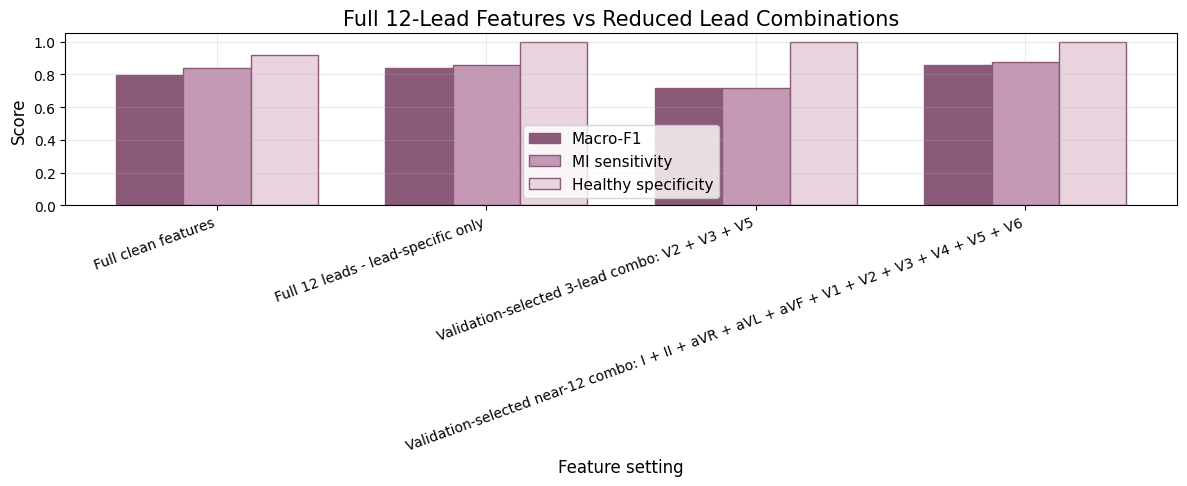

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_full_vs_small_vs_near12_comparison.png


In [51]:
# =========================
# Plot full vs small reduced vs near-12 comparison
# =========================

fig_path = FIGURE_DIR / "notebook7_full_vs_small_vs_near12_comparison.png"

plot_df = comparison_extended_df.copy()

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(12, 5))

plt.bar(
    x - width,
    plot_df["macro_f1"],
    width,
    label="Macro-F1",
    color=PURPLE_DARK,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x,
    plot_df["recall_sensitivity_mi"],
    width,
    label="MI sensitivity",
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.bar(
    x + width,
    plot_df["specificity_healthy"],
    width,
    label="Healthy specificity",
    color=PURPLE_LIGHT,
    edgecolor=PURPLE_DARK
)

plt.title("Full 12-Lead Features vs Reduced Lead Combinations")
plt.xlabel("Feature setting")
plt.ylabel("Score")
plt.xticks(x, plot_df["setting"], rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [52]:
# Leave-one-lead-out ablation analysis
# =========================

leave_one_out_results = []

for removed_lead in LEAD_ORDER:
    remaining_leads = [lead for lead in LEAD_ORDER if lead != removed_lead]

    removed_name = LEAD_DISPLAY_NAMES[removed_lead]
    remaining_names = " + ".join([LEAD_DISPLAY_NAMES[lead] for lead in remaining_leads])

    feature_set_name = f"Remove {removed_name}"

    cols = get_lead_specific_features(remaining_leads, clean_feature_cols)

    print("=" * 90)
    print("Running:", feature_set_name)
    print("Remaining leads:", remaining_names)
    print("Number of features:", len(cols))

    exp = run_feature_set_experiment(
        feature_set_name=feature_set_name,
        feature_cols=cols,
        k_max=200,
        model_label="SVM RBF"
    )

    for result in [exp["validation_result"], exp["test_result"]]:
        result["removed_lead"] = removed_lead
        result["removed_lead_display"] = removed_name
        result["remaining_leads"] = remaining_names
        leave_one_out_results.append(result)

leave_one_out_results_df = pd.DataFrame(leave_one_out_results)

leave_one_out_test_df = leave_one_out_results_df[
    leave_one_out_results_df["dataset"] == "test"
].copy()

display(
    leave_one_out_test_df
    .sort_values("macro_f1", ascending=False)[
        [
            "removed_lead_display",
            "accuracy",
            "recall_sensitivity_mi",
            "specificity_healthy",
            "macro_f1",
            "balanced_accuracy",
            "roc_auc",
            "tn", "fp", "fn", "tp",
            "n_input_features"
        ]
    ]
)

Running: Remove I
Remaining leads: II + III + aVR + aVL + aVF + V1 + V2 + V3 + V4 + V5 + V6
Number of features: 1001
Running: Remove II
Remaining leads: I + III + aVR + aVL + aVF + V1 + V2 + V3 + V4 + V5 + V6
Number of features: 1001
Running: Remove III
Remaining leads: I + II + aVR + aVL + aVF + V1 + V2 + V3 + V4 + V5 + V6
Number of features: 1001
Running: Remove aVR
Remaining leads: I + II + III + aVL + aVF + V1 + V2 + V3 + V4 + V5 + V6
Number of features: 1001
Running: Remove aVL
Remaining leads: I + II + III + aVR + aVF + V1 + V2 + V3 + V4 + V5 + V6
Number of features: 1001
Running: Remove aVF
Remaining leads: I + II + III + aVR + aVL + V1 + V2 + V3 + V4 + V5 + V6
Number of features: 1001
Running: Remove V1
Remaining leads: I + II + III + aVR + aVL + aVF + V2 + V3 + V4 + V5 + V6
Number of features: 1001
Running: Remove V2
Remaining leads: I + II + III + aVR + aVL + aVF + V1 + V3 + V4 + V5 + V6
Number of features: 1001
Running: Remove V3
Remaining leads: I + II + III + aVR + aVL + a

,removed_lead_display,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp,n_input_features
3,II,0.897059,0.875000,1.0,0.853763,0.937500,0.950893,12,0,7,49,1001
5,III,0.897059,0.875000,1.0,0.853763,0.937500,0.949405,12,0,7,49,1001
7,aVR,0.897059,0.875000,1.0,0.853763,0.937500,0.950893,12,0,7,49,1001
11,aVF,0.897059,0.875000,1.0,0.853763,0.937500,0.953869,12,0,7,49,1001
21,V5,0.897059,0.875000,1.0,0.853763,0.937500,0.947917,12,0,7,49,1001
15,V2,0.897059,0.875000,1.0,0.853763,0.937500,0.946429,12,0,7,49,1001
19,V4,0.897059,0.875000,1.0,0.853763,0.937500,0.950893,12,0,7,49,1001
17,V3,0.897059,0.875000,1.0,0.853763,0.937500,0.941964,12,0,7,49,1001
23,V6,0.897059,0.875000,1.0,0.853763,0.937500,0.949405,12,0,7,49,1001
1,I,0.882353,0.857143,1.0,0.836538,0.928571,0.952381,12,0,8,48,1001


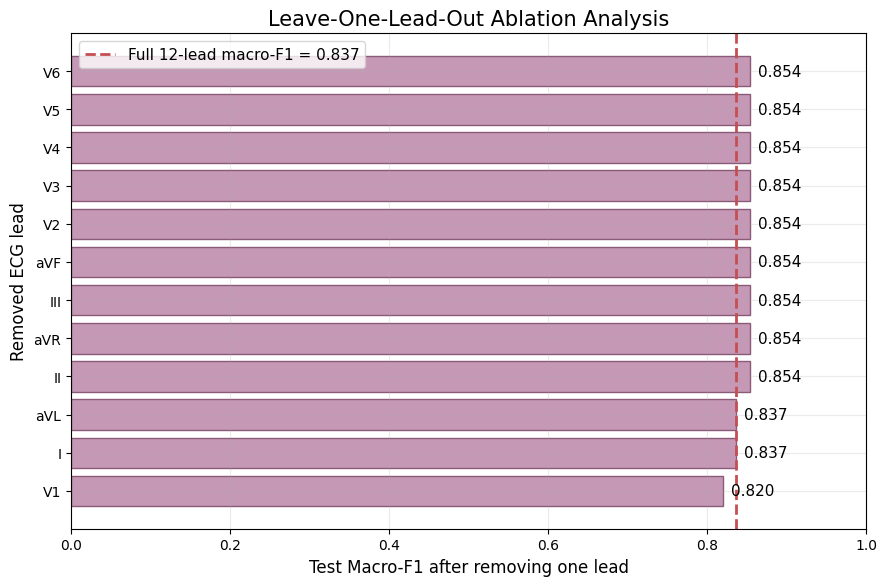

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_leave_one_lead_out_ablation.png


In [53]:
# =========================
# Plot leave-one-lead-out ablation
# =========================

fig_path = FIGURE_DIR / "notebook7_leave_one_lead_out_ablation.png"

plot_df = leave_one_out_test_df.copy()
plot_df = plot_df.sort_values("macro_f1", ascending=True)

full_12_macro_f1 = full_12_strict_test_row["macro_f1"]

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["removed_lead_display"],
    plot_df["macro_f1"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.axvline(
    full_12_macro_f1,
    color=RED_SOFT,
    linestyle="--",
    linewidth=2,
    label=f"Full 12-lead macro-F1 = {full_12_macro_f1:.3f}"
)

plt.title("Leave-One-Lead-Out Ablation Analysis")
plt.xlabel("Test Macro-F1 after removing one lead")
plt.ylabel("Removed ECG lead")
plt.xlim(0, 1)
plt.legend()
plt.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_df["macro_f1"]):
    plt.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

In [54]:
def get_removed_leads_from_combo(leads_string):
    selected = set(leads_string.split("+"))
    removed = [lead for lead in LEAD_ORDER if lead not in selected]
    return " + ".join([LEAD_DISPLAY_NAMES[lead] for lead in removed])

near12_test_df["removed_leads"] = near12_test_df["leads"].apply(get_removed_leads_from_combo)
near12_validation_df["removed_leads"] = near12_validation_df["leads"].apply(get_removed_leads_from_combo)

display(
    near12_test_df
    .sort_values("macro_f1", ascending=False)
    .head(15)[
        [
            "combo_size",
            "removed_leads",
            "accuracy",
            "recall_sensitivity_mi",
            "specificity_healthy",
            "macro_f1",
            "balanced_accuracy",
            "roc_auc",
            "tn", "fp", "fn", "tp"
        ]
    ]
)

,combo_size,removed_leads,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,balanced_accuracy,roc_auc,tn,fp,fn,tp
127,10,I + aVR,0.926471,0.910714,1.0,0.890429,0.955357,0.952381,12,0,5,51
131,10,I + II,0.911765,0.892857,1.0,0.871698,0.946429,0.955357,12,0,6,50
115,10,I + V4,0.911765,0.892857,1.0,0.871698,0.946429,0.955357,12,0,6,50
107,10,II + aVR,0.911765,0.892857,1.0,0.871698,0.946429,0.947917,12,0,6,50
61,10,aVR + V4,0.911765,0.892857,1.0,0.871698,0.946429,0.958333,12,0,6,50
103,10,II + aVF,0.911765,0.892857,1.0,0.871698,0.946429,0.950893,12,0,6,50
35,10,aVF + V4,0.897059,0.875000,1.0,0.853763,0.937500,0.956845,12,0,7,49
37,10,aVF + V3,0.897059,0.875000,1.0,0.853763,0.937500,0.946429,12,0,7,49
3,10,V4 + V6,0.897059,0.875000,1.0,0.853763,0.937500,0.956845,12,0,7,49
7,10,V3 + V6,0.897059,0.875000,1.0,0.853763,0.937500,0.946429,12,0,7,49


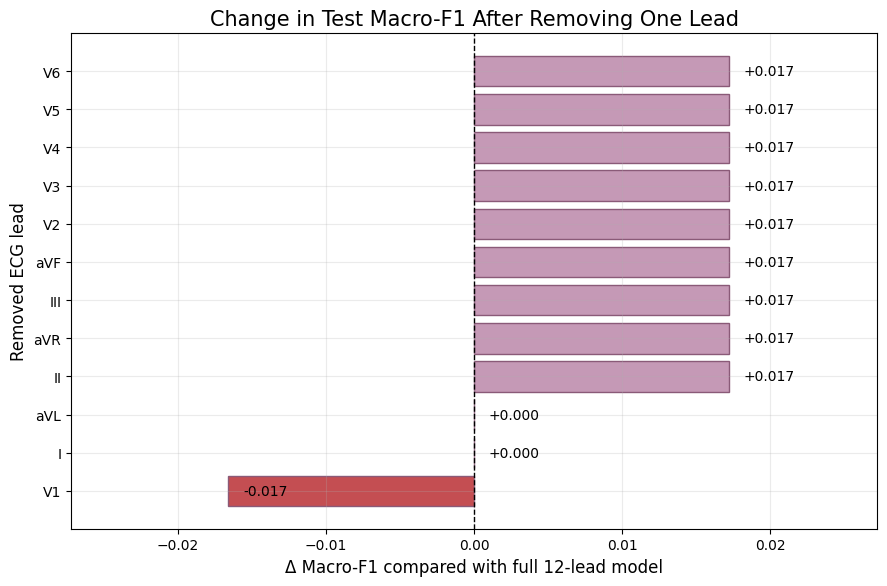

Saved figure to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook7_leave_one_lead_out_delta_macro_f1_fixed.png


In [56]:
# =========================
# Improved leave-one-lead-out delta plot
# =========================

leave_one_out_test_df["delta_macro_f1_vs_full12"] = (
    leave_one_out_test_df["macro_f1"] - full_12_strict_test_row["macro_f1"]
)

plot_df = leave_one_out_test_df.sort_values(
    "delta_macro_f1_vs_full12",
    ascending=True
).copy()

fig_path = FIGURE_DIR / "notebook7_leave_one_lead_out_delta_macro_f1_fixed.png"

plt.figure(figsize=(9, 6))

colors = [
    RED_SOFT if x < 0 else PURPLE_MAIN
    for x in plot_df["delta_macro_f1_vs_full12"]
]

plt.barh(
    plot_df["removed_lead_display"],
    plot_df["delta_macro_f1_vs_full12"],
    color=colors,
    edgecolor=PURPLE_DARK
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Change in Test Macro-F1 After Removing One Lead")
plt.xlabel("Δ Macro-F1 compared with full 12-lead model")
plt.ylabel("Removed ECG lead")
plt.grid(axis="x", alpha=0.25)

# set symmetric x-axis limit
max_abs_delta = max(abs(plot_df["delta_macro_f1_vs_full12"].min()),
                    abs(plot_df["delta_macro_f1_vs_full12"].max()))
plt.xlim(-max_abs_delta - 0.01, max_abs_delta + 0.01)

# annotate values safely inside the plot area
for i, value in enumerate(plot_df["delta_macro_f1_vs_full12"]):
    if value < 0:
        x_text = value + 0.001
        ha = "left"
    elif value > 0:
        x_text = value + 0.001
        ha = "left"
    else:
        x_text = 0.001
        ha = "left"

    plt.text(
        x_text,
        i,
        f"{value:+.3f}",
        va="center",
        ha=ha,
        fontsize=10
    )

plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure to:", fig_path)

# Save outputs

In [57]:
predefined_results_path = TABLE_DIR / "notebook7_predefined_lead_group_results.csv"
single_lead_results_path = TABLE_DIR / "notebook7_single_lead_results.csv"
topk_results_path = TABLE_DIR / "notebook7_topk_lead_combination_results.csv"
combo2_results_path = TABLE_DIR / "notebook7_exhaustive_2lead_results.csv"
combo3_results_path = TABLE_DIR / "notebook7_exhaustive_3lead_results.csv"
all_combo_results_path = TABLE_DIR / "notebook7_all_reduced_combo_results.csv"
full_vs_reduced_path = TABLE_DIR / "notebook7_full_vs_reduced_comparison.csv"

predefined_results_df.to_csv(predefined_results_path, index=False, encoding="utf-8-sig")
single_lead_results_df.to_csv(single_lead_results_path, index=False, encoding="utf-8-sig")
topk_results_df.to_csv(topk_results_path, index=False, encoding="utf-8-sig")
combo2_results_df.to_csv(combo2_results_path, index=False, encoding="utf-8-sig")
combo3_results_df.to_csv(combo3_results_path, index=False, encoding="utf-8-sig")
all_combo_results_df.to_csv(all_combo_results_path, index=False, encoding="utf-8-sig")
full_vs_reduced_df.to_csv(full_vs_reduced_path, index=False, encoding="utf-8-sig")

print("Saved tables:")
print(predefined_results_path)
print(single_lead_results_path)
print(topk_results_path)
print(combo2_results_path)
print(combo3_results_path)
print(all_combo_results_path)
print(full_vs_reduced_path)

Saved tables:
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook7_predefined_lead_group_results.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook7_single_lead_results.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook7_topk_lead_combination_results.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook7_exhaustive_2lead_results.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook7_exhaustive_3lead_results.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook7_all_reduced_combo_results.csv
d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook7_full_vs_reduced_comparison.csv


In [58]:
notebook7_summary = {
    "model": "SVM RBF",
    "task": "Binary MI detection",
    "label": "0 = Healthy Control, 1 = Myocardial Infarction",
    "important_note": "No MI localization labels were used. Anatomical lead groups were used only as feature groups.",
    
    "full_clean_features_test_macro_f1": float(full_clean_test_row["macro_f1"]),
    "full_12_lead_specific_test_macro_f1": float(full_12_strict_test_row["macro_f1"]),
    
    "best_single_lead_by_test_macro_f1": single_lead_test_df.iloc[0]["lead_display"],
    "best_single_lead_test_macro_f1": float(single_lead_test_df.iloc[0]["macro_f1"]),
    
    "validation_selected_3lead_combination": best_combo_name,
    "validation_selected_3lead_test_macro_f1": float(best_combo_test_row["macro_f1"]),
    
    "validation_selected_near12_combination": best_near12_name,
    "validation_selected_near12_test_macro_f1": float(best_near12_test_row["macro_f1"]),
    "validation_selected_near12_test_accuracy": float(best_near12_test_row["accuracy"]),
    "validation_selected_near12_test_sensitivity": float(best_near12_test_row["recall_sensitivity_mi"]),
    "validation_selected_near12_test_specificity": float(best_near12_test_row["specificity_healthy"]),
    
    "main_interpretation": (
        "Very small 2-3 lead combinations were less stable, while near-12 lead combinations "
        "preserved or slightly improved performance compared with the full 12-lead lead-specific model."
    )
}

summary_path = TABLE_DIR / "notebook7_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(notebook7_summary, f, indent=4)

print(json.dumps(notebook7_summary, indent=4))

{
    "model": "SVM RBF",
    "task": "Binary MI detection",
    "label": "0 = Healthy Control, 1 = Myocardial Infarction",
    "important_note": "No MI localization labels were used. Anatomical lead groups were used only as feature groups.",
    "full_clean_features_test_macro_f1": 0.7956730769230769,
    "full_12_lead_specific_test_macro_f1": 0.8365384615384616,
    "best_single_lead_by_test_macro_f1": "III",
    "best_single_lead_test_macro_f1": 0.7794594594594595,
    "validation_selected_3lead_combination": "V2 + V3 + V5",
    "validation_selected_3lead_test_macro_f1": 0.7166666666666667,
    "validation_selected_near12_combination": "I + II + aVR + aVL + aVF + V1 + V2 + V3 + V4 + V5 + V6",
    "validation_selected_near12_test_macro_f1": 0.853763440860215,
    "validation_selected_near12_test_accuracy": 0.8970588235294118,
    "validation_selected_near12_test_sensitivity": 0.875,
    "validation_selected_near12_test_specificity": 1.0,
    "main_interpretation": "Very small 2-3 lea

In [59]:
print("Notebook 7 completed.")

print("\nBest single lead by test macro-F1:")
display(single_lead_test_df.head(5)[
    [
        "lead_display",
        "accuracy",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "macro_f1",
        "roc_auc"
    ]
])

print("\nBest reduced lead combination selected on validation:")
print(best_combo_name)

print("\nFull vs reduced comparison:")
display(full_vs_reduced_df[
    [
        "setting",
        "accuracy",
        "recall_sensitivity_mi",
        "specificity_healthy",
        "macro_f1",
        "roc_auc",
        "tn", "fp", "fn", "tp"
    ]
])

Notebook 7 completed.

Best single lead by test macro-F1:


,lead_display,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,roc_auc
5,III,0.867647,0.910714,0.666667,0.779459,0.873512
11,aVF,0.838235,0.839286,0.833333,0.770200,0.883929
9,aVL,0.852941,0.892857,0.666667,0.762238,0.909226
23,V6,0.808824,0.785714,0.916667,0.749929,0.925595
13,V1,0.823529,0.839286,0.750000,0.743396,0.822917



Best reduced lead combination selected on validation:
V2 + V3 + V5

Full vs reduced comparison:


,setting,accuracy,recall_sensitivity_mi,specificity_healthy,macro_f1,roc_auc,tn,fp,fn,tp
0,Full clean features,0.852941,0.839286,0.916667,0.795673,0.937500,11,1,9,47
1,Full 12 leads - lead-specific only,0.882353,0.857143,1.000000,0.836538,0.950893,12,0,8,48
2,Best reduced combo: V2 + V3 + V5,0.808824,0.767857,1.000000,0.758668,0.918155,12,0,13,43
